In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [174]:
df = pd.read_csv('HR_comma_sep.csv')
df.sample(6)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
383,0.38,0.51,2,159,3,0,1,0,sales,medium
11837,0.70,0.95,3,158,2,0,0,0,product_mng,medium
10266,0.54,0.52,5,170,4,0,0,0,technical,high
9803,0.51,0.58,3,141,3,0,0,0,hr,low
8546,0.49,0.89,4,240,2,0,0,0,RandD,medium
2721,0.24,0.62,5,169,4,0,0,0,support,medium


In [175]:
df.shape

(14999, 10)

In [176]:
df2 = df.copy()
df2

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [177]:
left = df[df.left == 1]
left.shape

(3571, 10)

In [178]:
retained = df[df.left == 0]
retained.shape

(11428, 10)

In [179]:
categorical_cols = df2.select_dtypes(include=['object']).columns
categorical_cols

Index(['Department', 'salary'], dtype='object')

In [180]:
df_numerical = df2.drop(categorical_cols, axis=1)
df_numerical

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
0,0.38,0.53,2,157,3,0,1,0
1,0.80,0.86,5,262,6,0,1,0
2,0.11,0.88,7,272,4,0,1,0
3,0.72,0.87,5,223,5,0,1,0
4,0.37,0.52,2,159,3,0,1,0
...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0
14995,0.37,0.48,2,160,3,0,1,0
14996,0.37,0.53,2,143,3,0,1,0
14997,0.11,0.96,6,280,4,0,1,0


In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [182]:
g = df_numerical.groupby('left')
g.mean()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


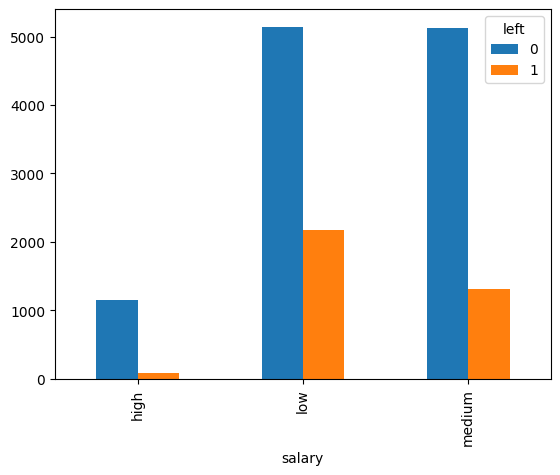

In [183]:
pd.crosstab(df.salary, df.left).plot(kind='bar')
plt.show()

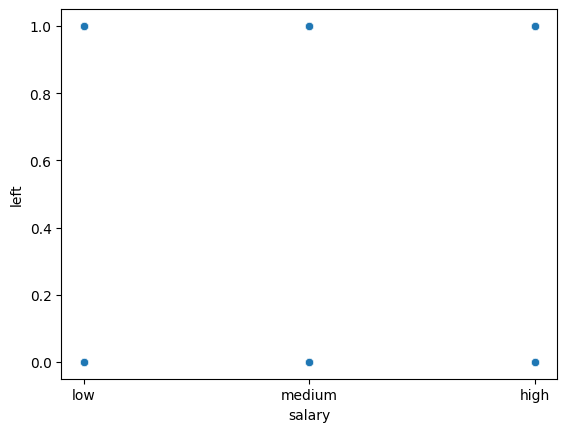

In [184]:
sns.scatterplot(data=df, x='salary', y='left')
plt.show()

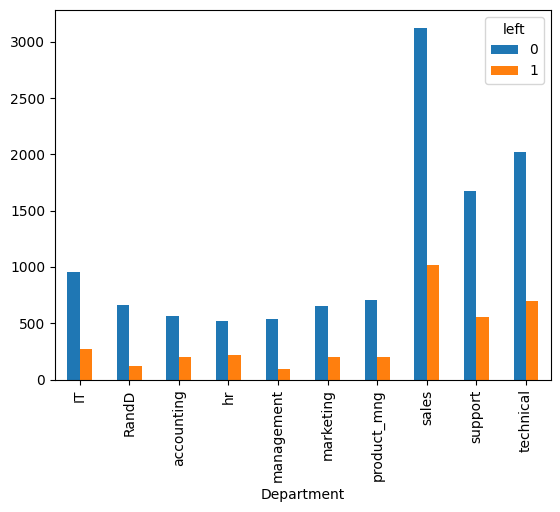

In [185]:
pd.crosstab(df.Department, df.left).plot(kind='bar')
plt.show()

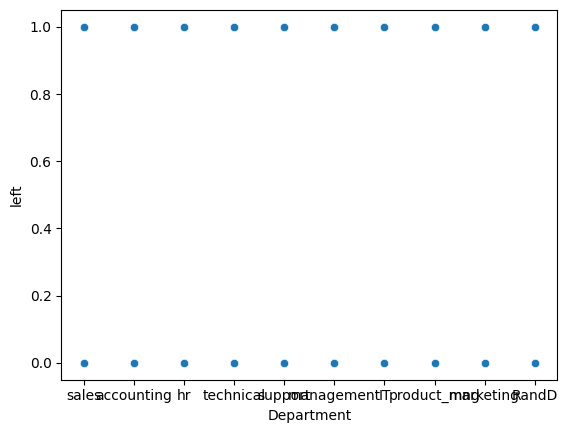

In [186]:
sns.scatterplot(data=df, x='Department', y='left')
plt.show()

From the data analysis and plotting, thr feature 'left' is dependend mainly on:

1. satisfaction_level
2. average_montly_hours
3. Work_accident
4. promotion_last_5years
5. salary

In [187]:
df_final = df[['satisfaction_level', 'average_montly_hours', 'Work_accident', 'promotion_last_5years', 'salary']]
df_final.sample(5)

,satisfaction_level,average_montly_hours,Work_accident,promotion_last_5years,salary
6322,0.26,99,0,0,medium
8477,0.60,140,0,0,low
14331,0.14,158,1,0,low
13983,0.84,178,0,0,low
3126,0.49,196,0,0,low


<Axes: xlabel='Work_accident'>

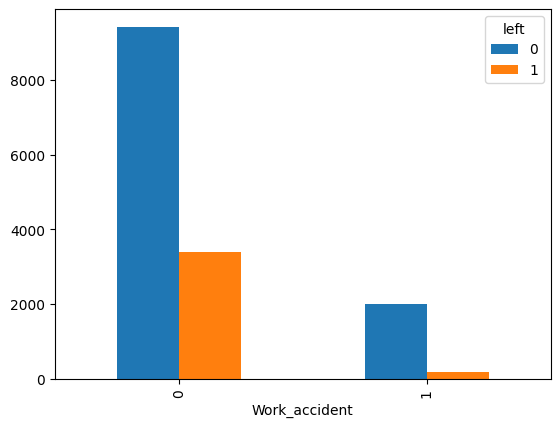

In [188]:
pd.crosstab(df.Work_accident, df.left).plot(kind='bar')

In [189]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop=['medium'])

In [190]:
dfhe = ohe.fit_transform(df_final[['salary']])
dfhe = pd.DataFrame(dfhe, columns=ohe.get_feature_names_out(['salary']))
dfhe

,salary_high,salary_low
0,0.0,1.0
1,0.0,0.0
2,0.0,0.0
3,0.0,1.0
4,0.0,1.0
...,...,...
14994,0.0,1.0
14995,0.0,1.0
14996,0.0,1.0
14997,0.0,1.0


In [191]:
X = pd.concat([df_final.drop(['salary'], axis=1), dfhe], axis=1)
X.head(6)

,satisfaction_level,average_montly_hours,Work_accident,promotion_last_5years,salary_high,salary_low
0,0.38,157,0,0,0.0,1.0
1,0.80,262,0,0,0.0,0.0
2,0.11,272,0,0,0.0,0.0
3,0.72,223,0,0,0.0,1.0
4,0.37,159,0,0,0.0,1.0
5,0.41,153,0,0,0.0,1.0


In [192]:
Y = df['left']
Y

,left
0,1
1,1
2,1
3,1
4,1
...,...
14994,1
14995,1
14996,1
14997,1


In [193]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1,  random_state=42)

In [194]:
X_train.shape

(13499, 6)

In [195]:
X_test.shape

(1500, 6)

In [196]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression().fit(X_train, Y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [197]:
Y_test

,left
6723,0
6473,0
4679,0
862,1
7286,0
...,...
2655,0
4606,0
10904,0
14862,1


In [198]:
model.predict(X_test)

array([0, 0, 0, ..., 0, 1, 0])

In [199]:
model.score(X_test, Y_test)

0.764

In [200]:
model.predict_proba(X_test)

array([[0.94823483, 0.05176517],
       [0.88101564, 0.11898436],
       [0.76126168, 0.23873832],
       ...,
       [0.79125559, 0.20874441],
       [0.31396417, 0.68603583],
       [0.86799155, 0.13200845]])